<a href="https://www.kaggle.com/code/lalit7881/global-inflation-vs-interest-rates-eda?scriptVersionId=312750766" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/central_bank_rates.csv
/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/README.md
/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/macro_news_sentiment.csv
/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/cpi_inflation_worldbank_annual.csv
/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/cpi_inflation.csv
/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present/rates_vs_cpi_panel.csv


## Loading dataset

In [2]:
import os

# Default Kaggle input path
INPUT_DIR = '/kaggle/input/datasets/belbino/global-inflation-vs-interest-rates-2021-present'

# If running locally, switch to current directory
if not os.path.exists(INPUT_DIR):
    INPUT_DIR = '.'

In [3]:
rates_df  = pd.read_csv(f'{INPUT_DIR}/central_bank_rates.csv', parse_dates=['date'])
cpi_df    = pd.read_csv(f'{INPUT_DIR}/cpi_inflation.csv', parse_dates=['date'])
wb_cpi_df = pd.read_csv(f'{INPUT_DIR}/cpi_inflation_worldbank_annual.csv')
panel_df  = pd.read_csv(f'{INPUT_DIR}/rates_vs_cpi_panel.csv', parse_dates=['date'])
news_df   = pd.read_csv(f'{INPUT_DIR}/macro_news_sentiment.csv', parse_dates=['date'])

In [4]:
# Convert to month-start format
for df in [rates_df, cpi_df, panel_df]:
    df['date'] = pd.to_datetime(df['date']).dt.to_period('M').dt.to_timestamp()

In [5]:
def dataset_summary(name, df):
    if 'date' in df.columns:
        min_date = df['date'].min()
        max_date = df['date'].max()
    elif 'year' in df.columns:
        min_date = df['year'].min()
        max_date = df['year'].max()
    else:
        min_date, max_date = '-', '-'

    print(f"{name}")
    print(f"Shape : {df.shape}")
    print(f"Range : {min_date} → {max_date}")
    print("-" * 40)


# Print summaries
dataset_summary("Central Bank Rates", rates_df)
dataset_summary("CPI Inflation", cpi_df)
dataset_summary("World Bank CPI", wb_cpi_df)
dataset_summary("Rates vs CPI Panel", panel_df)
dataset_summary("News Sentiment", news_df)

Central Bank Rates
Shape : (136, 9)
Range : 2015-01-01 00:00:00 → 2026-04-01 00:00:00
----------------------------------------
CPI Inflation
Shape : (135, 29)
Range : 2015-01-01 00:00:00 → 2026-03-01 00:00:00
----------------------------------------
World Bank CPI
Shape : (237, 4)
Range : 2015 → 2024
----------------------------------------
Rates vs CPI Panel
Shape : (1183, 8)
Range : 2015-01-01 00:00:00 → 2026-04-01 00:00:00
----------------------------------------
News Sentiment
Shape : (468, 10)
Range : 2021-05-12 00:00:00 → 2026-04-17 00:00:00
----------------------------------------


In [6]:
rates_df.head()
cpi_df.head()
news_df.head()

,date,title,source,sentiment,is_hawkish,is_dovish,description,url,published_at,sentiment_cat
0,2021-05-12,"US CPI jumps 4.2% year over year, highest sinc...",Reuters,0.2732,False,False,NaN,NaN,2021-05-12 00:00:00,positive
1,2021-06-10,Fed insists inflation surge is transitory; no ...,Bloomberg,-0.2960,False,True,NaN,NaN,2021-06-10 00:00:00,negative
2,2021-10-13,"US CPI hits 5.4%, broadest inflation reading i...",WSJ,0.0000,False,False,NaN,NaN,2021-10-13 00:00:00,neutral
3,2021-11-03,Fed begins tapering bond purchases as inflatio...,FT,-0.2732,True,False,NaN,NaN,2021-11-03 00:00:00,negative
4,2021-11-10,"UK CPI rises to 4.2%, Bank of England signals ...",Guardian,0.0000,True,False,NaN,NaN,2021-11-10 00:00:00,neutral


In [7]:
rates_df.info()
cpi_df.info()
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   136 non-null    datetime64[ns]
 1   fed_funds_rate         136 non-null    float64       
 2   ecb_deposit_rate       136 non-null    float64       
 3   boe_base_rate          136 non-null    float64       
 4   rbi_repo_rate          136 non-null    float64       
 5   us_10y_treasury        136 non-null    float64       
 6   japan_policy_rate      136 non-null    float64       
 7   canada_policy_rate     136 non-null    float64       
 8   australia_policy_rate  136 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 9.7 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------          

In [8]:
rates_df.isnull().sum()
cpi_df.isnull().sum()
news_df.isnull().sum()

date              0
title             0
source            0
sentiment         0
is_hawkish        0
is_dovish         0
description      45
url              45
published_at      0
sentiment_cat     0
dtype: int64

## EDA

In [9]:
COLORS = {
    'United States': '#2563eb',      # blue
    'Eurozone': '#16a34a',           # green
    'United Kingdom': '#dc2626',     # red
    'India': '#f59e0b'               # orange
}
plt.rcParams['figure.facecolor'] = 'white'

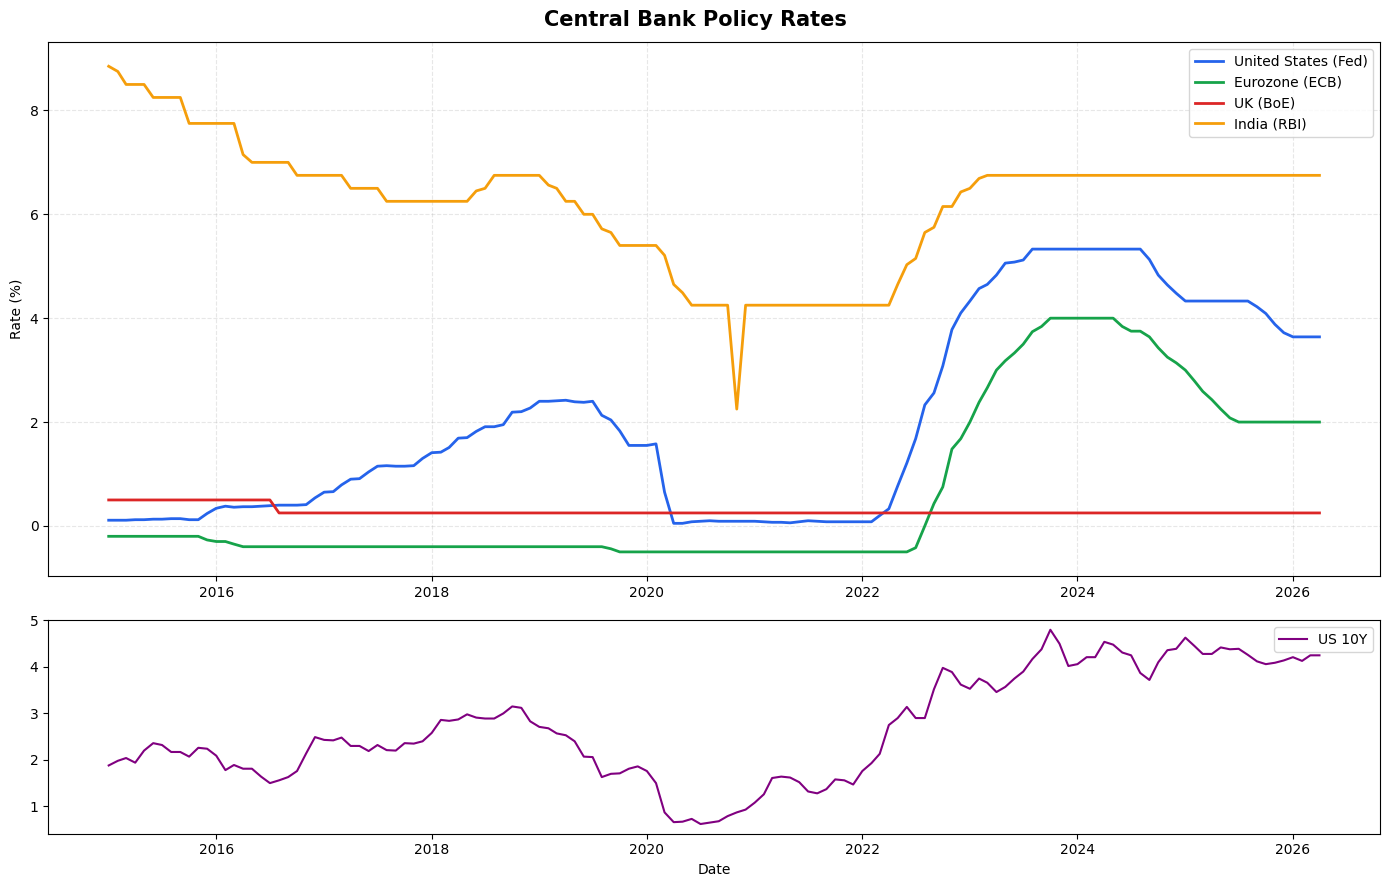

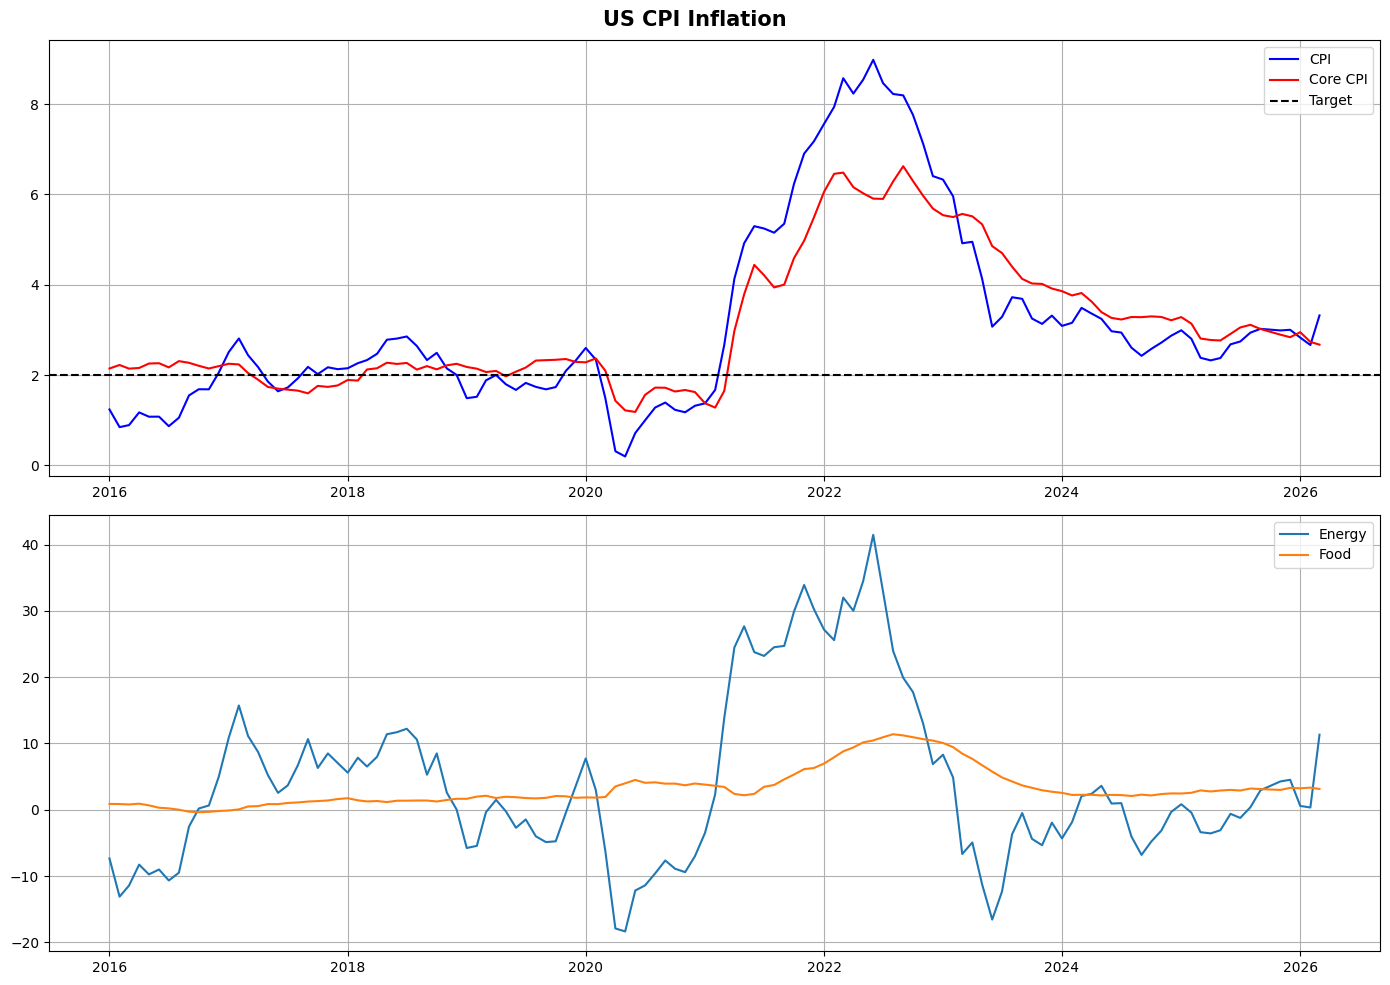

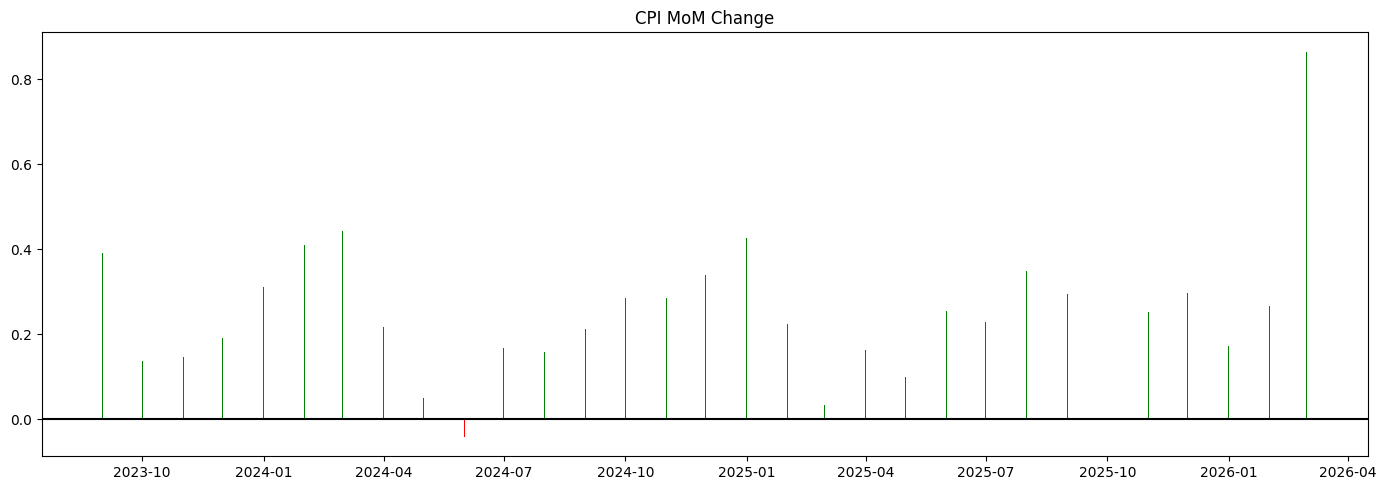

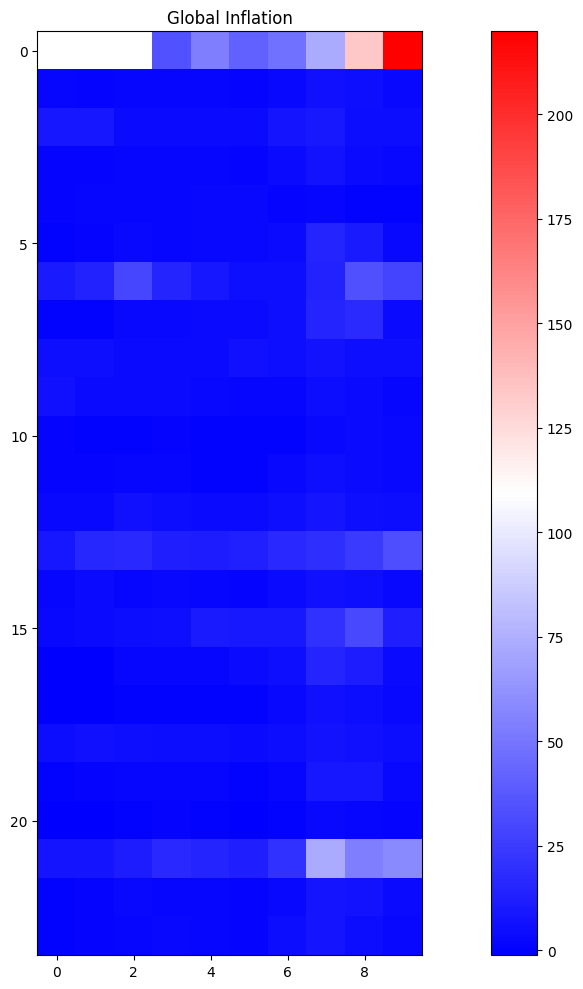

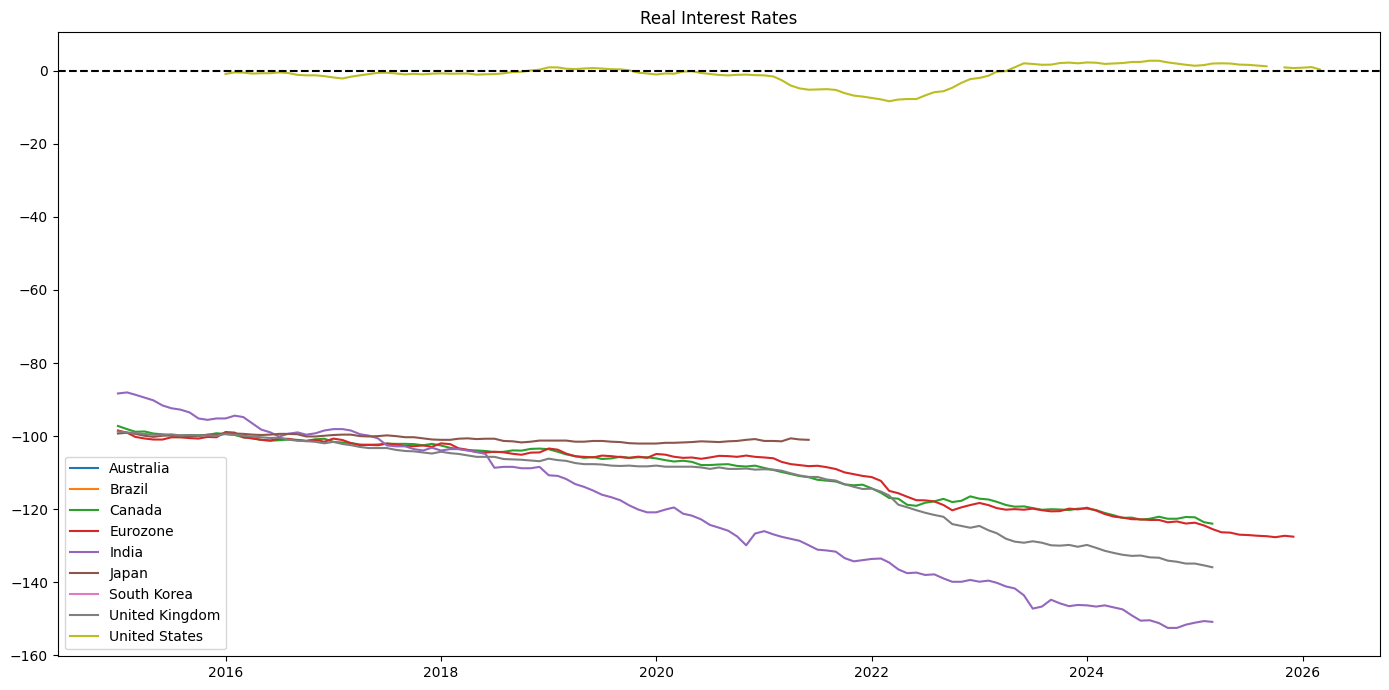

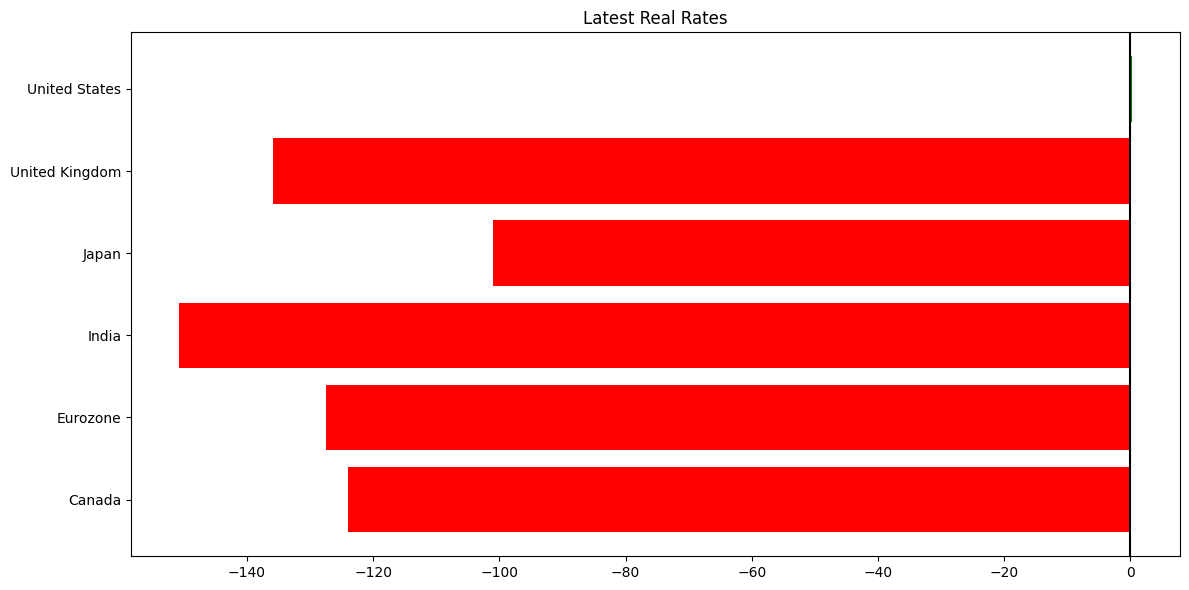

          economy       date  policy_rate  cpi_yoy_pct  real_rate_pct  \
0          Canada 2025-03-01         5.25     129.1809       -123.931   
1        Eurozone 2025-12-01         2.00     129.4900       -127.490   
2           India 2025-03-01         6.75     157.5517       -150.802   
3           Japan 2021-06-01         0.30     101.2980       -100.998   
4  United Kingdom 2025-03-01         0.25     136.1000       -135.850   
5   United States 2026-03-01         3.64       3.3200          0.320   

   rate_change_bps rate_action  cycle_cumul_bps  
0              0.0        hold            475.0  
1              0.0        hold           -200.0  
2              0.0        hold            450.0  
3              0.0        hold              0.0  
4              0.0        hold            -25.0  
5              0.0        hold           -169.0  


In [10]:
# ==============================
# 📦 IMPORTS & SETUP
# ==============================
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap


# ==============================
# 📊 1. CENTRAL BANK RATES
# ==============================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                gridspec_kw={'height_ratios': [3, 1.2]})

fig.suptitle('Central Bank Policy Rates', fontsize=15, fontweight='bold')

RATE_COLS = {
    'fed_funds_rate':    ('United States (Fed)', COLORS['United States']),
    'ecb_deposit_rate':  ('Eurozone (ECB)', COLORS['Eurozone']),
    'boe_base_rate':     ('UK (BoE)', COLORS['United Kingdom']),
    'rbi_repo_rate':     ('India (RBI)', COLORS['India']),
}

for col, (label, color) in RATE_COLS.items():
    if col in rates_df.columns:
        s = rates_df.dropna(subset=[col])
        ax1.plot(s['date'], s[col], label=label, color=color, linewidth=2)

ax1.set_ylabel('Rate (%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)

# US 10Y
if 'us_10y_treasury' in rates_df.columns:
    s = rates_df.dropna(subset=['us_10y_treasury'])
    ax2.plot(s['date'], s['us_10y_treasury'], color='purple', label='US 10Y')

ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.savefig('01_rates.png')
plt.show()


# ==============================
# 📊 2. CPI ANALYSIS
# ==============================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

fig.suptitle('US CPI Inflation', fontsize=15, fontweight='bold')

# Main CPI
for col, label, color in [
    ('us_cpi_all_items_yoy_pct', 'CPI', 'blue'),
    ('us_core_cpi_yoy_pct', 'Core CPI', 'red'),
]:
    if col in cpi_df.columns:
        s = cpi_df.dropna(subset=[col])
        ax1.plot(s['date'], s[col], label=label, color=color)

ax1.axhline(2, linestyle='--', color='black', label='Target')
ax1.legend()
ax1.grid(True)

# Components
for col, label in [
    ('us_energy_cpi_yoy_pct', 'Energy'),
    ('us_food_cpi_yoy_pct', 'Food'),
]:
    if col in cpi_df.columns:
        s = cpi_df.dropna(subset=[col])
        ax2.plot(s['date'], s[col], label=label)

ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('02_cpi.png')
plt.show()


# ==============================
# 📊 3. CPI MOM BAR
# ==============================
col = 'us_cpi_all_items_mom_pct'

if col in cpi_df.columns:
    s = cpi_df.dropna(subset=[col]).tail(30)

    fig, ax = plt.subplots(figsize=(14, 5))

    colors = ['green' if v > 0 else 'red' for v in s[col]]
    ax.bar(s['date'], s[col], color=colors)

    ax.axhline(0, color='black')
    ax.set_title('CPI MoM Change')

    plt.tight_layout()
    plt.savefig('03_cpi_mom.png')
    plt.show()


# ==============================
# 📊 4. GLOBAL HEATMAP
# ==============================
pivot = wb_cpi_df.pivot_table(
    index='country_name', columns='year', values='cpi_annual_pct'
)

cmap = LinearSegmentedColormap.from_list(
    'inflation', ['blue', 'white', 'red']
)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(pivot, cmap=cmap)

plt.colorbar(im)
ax.set_title('Global Inflation')

plt.tight_layout()
plt.savefig('04_heatmap.png')
plt.show()


# ==============================
# 📊 5. REAL RATES LINE
# ==============================
fig, ax = plt.subplots(figsize=(14, 7))

for eco in panel_df['economy'].dropna().unique():
    sub = panel_df[panel_df['economy'] == eco]
    ax.plot(sub['date'], sub['real_rate_pct'], label=eco)

ax.axhline(0, linestyle='--', color='black')
ax.legend()
ax.set_title('Real Interest Rates')

plt.tight_layout()
plt.savefig('05_real_rates.png')
plt.show()


# ==============================
# 📊 6. REAL RATES BAR
# ==============================
latest_real = (
    panel_df.dropna(subset=['real_rate_pct'])
    .groupby('economy')
    .last()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['red' if v < 0 else 'green' for v in latest_real['real_rate_pct']]
ax.barh(latest_real['economy'], latest_real['real_rate_pct'], color=colors)

ax.axvline(0, color='black')
ax.set_title('Latest Real Rates')

plt.tight_layout()
plt.savefig('06_real_rates_bar.png')
plt.show()

print(latest_real)

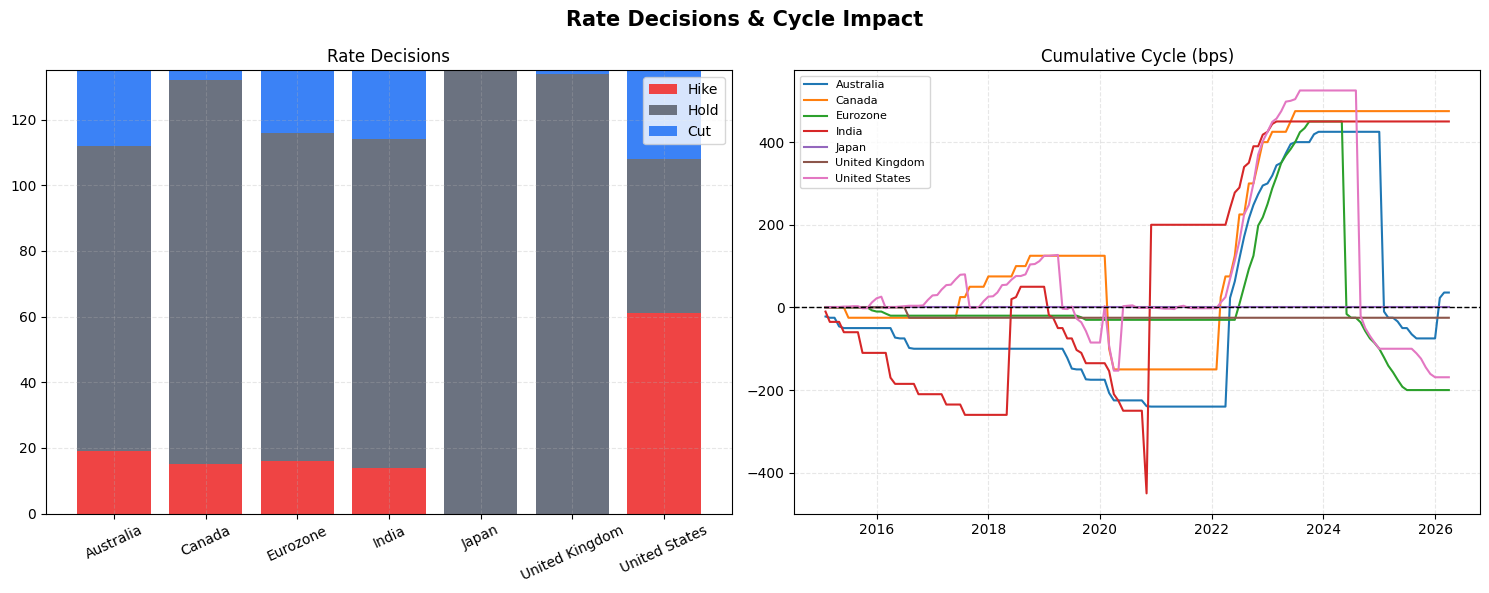

Saved → 07_hike_cut_cycles.png


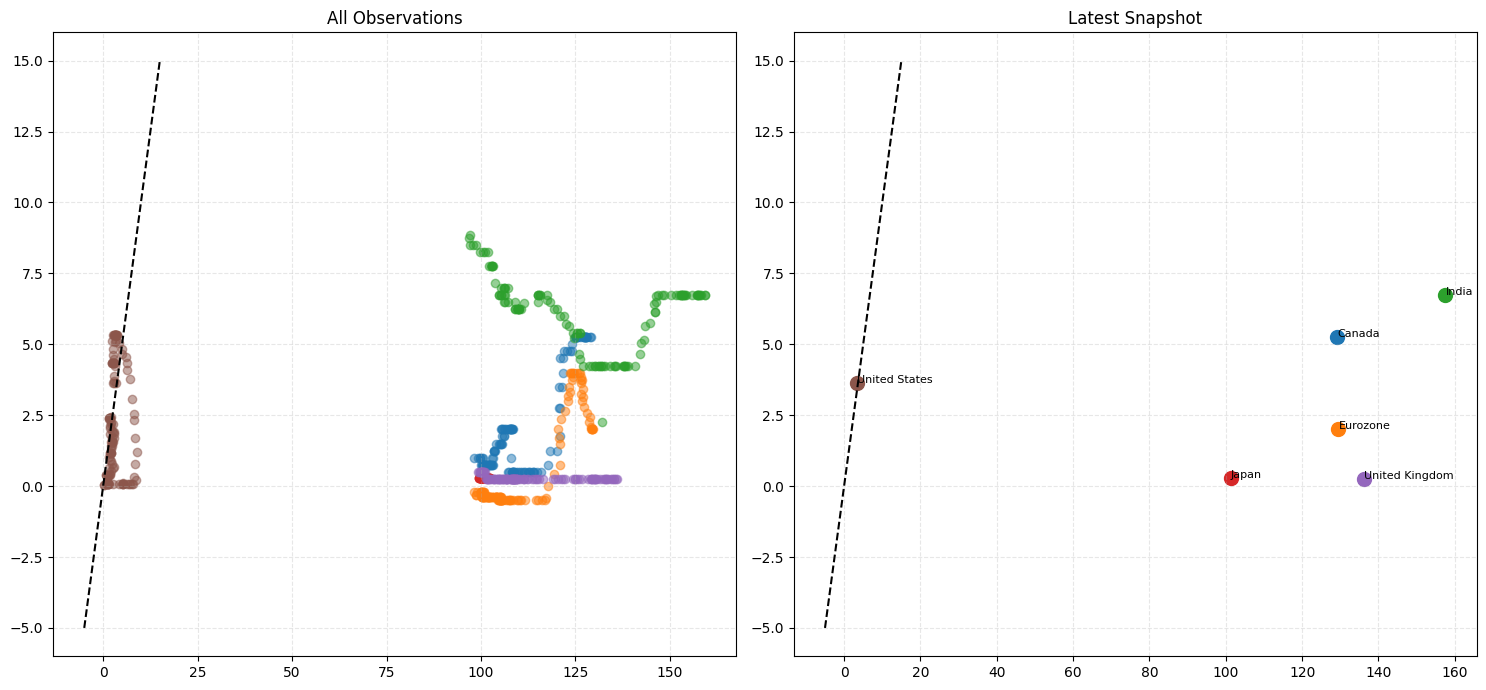

Saved → 08_rate_vs_cpi.png


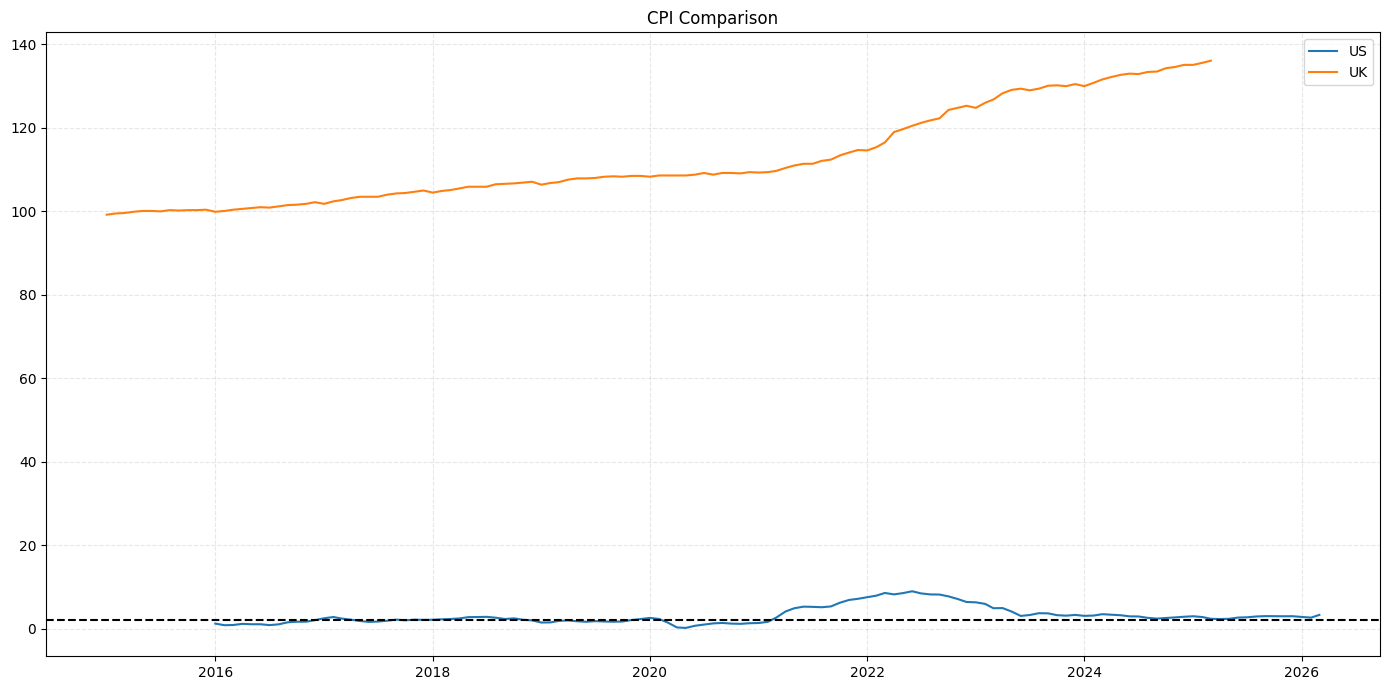

Saved → 09_cpi_compare.png


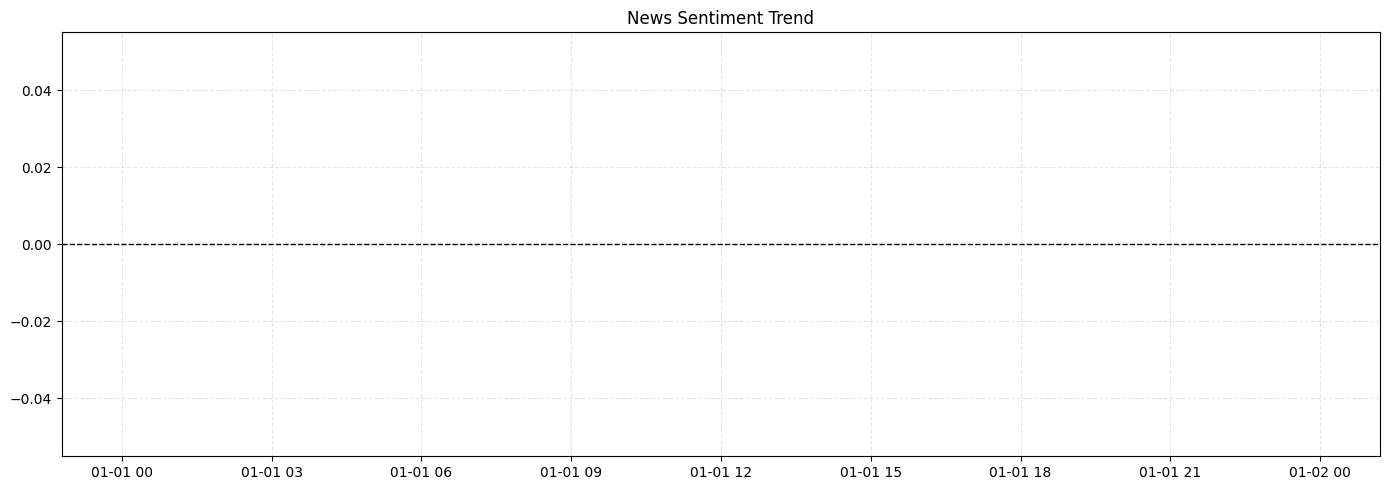

Saved → 10_sentiment.png
📊 KEY INSIGHTS

🏦 Latest Policy Rates
fed_funds_rate      : 3.64%
ecb_deposit_rate    : 2.00%
boe_base_rate       : 0.25%
rbi_repo_rate       : 6.75%

📊 CPI
us_cpi_all_items_yoy_pct : +3.32%
us_core_cpi_yoy_pct      : +2.67%

📰 News
Total: 468
Avg Sentiment: -0.163


In [11]:
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--"
})

# 🎨 Central color system (consistent everywhere)
COLORS = {
    'United States': '#1f77b4',
    'Eurozone': '#2ca02c',
    'United Kingdom': '#d62728',
    'India': '#ff7f0e',
    'Japan': '#9467bd',
    'Canada': '#17becf',
    'Brazil': '#8c564b',
    'South Korea': '#e377c2'
}

# ==============================
# 🧠 HELPER FUNCTIONS
# ==============================
def save_plot(name):
    plt.tight_layout()
    plt.savefig(name, dpi=140, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved → {name}")

def format_percent(ax):
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

def add_zero_line(ax):
    ax.axhline(0, color='black', linestyle='--', linewidth=1)

# ==============================
# 📊 7. RATE DECISION ANALYSIS
# ==============================
decisions = (
    panel_df.dropna(subset=['rate_action'])
    .groupby(['economy', 'rate_action'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['hike', 'hold', 'cut'], fill_value=0)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

fig.suptitle('Rate Decisions & Cycle Impact', fontsize=15, fontweight='bold')

# 🔹 Stacked bar
x = np.arange(len(decisions))
ax1.bar(x, decisions['hike'], label='Hike', color='#ef4444')
ax1.bar(x, decisions['hold'], bottom=decisions['hike'], label='Hold', color='#6b7280')
ax1.bar(x, decisions['cut'], bottom=decisions['hike']+decisions['hold'], label='Cut', color='#3b82f6')

ax1.set_xticks(x)
ax1.set_xticklabels(decisions.index, rotation=25)
ax1.set_title('Rate Decisions')
ax1.legend()

# 🔹 Cycle line
for eco in panel_df['economy'].dropna().unique():
    sub = panel_df[panel_df['economy'] == eco].dropna(subset=['cycle_cumul_bps'])
    if sub.empty: continue
    ax2.plot(sub['date'], sub['cycle_cumul_bps'], label=eco)

add_zero_line(ax2)
ax2.set_title('Cumulative Cycle (bps)')
ax2.legend(fontsize=8)

save_plot('07_hike_cut_cycles.png')

# ==============================
# 📊 8. RATE vs CPI SCATTER
# ==============================
clean = panel_df.dropna(subset=['policy_rate', 'cpi_yoy_pct'])

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# 🔹 Scatter all
for eco in clean['economy'].unique():
    sub = clean[clean['economy'] == eco]
    axes[0].scatter(sub['cpi_yoy_pct'], sub['policy_rate'], alpha=0.5)

axes[0].plot([-5, 15], [-5, 15], '--', color='black')
axes[0].set_title('All Observations')

# 🔹 Latest snapshot
latest_panel = clean.groupby('economy').last().reset_index()

for _, r in latest_panel.iterrows():
    axes[1].scatter(r['cpi_yoy_pct'], r['policy_rate'], s=100)
    axes[1].text(r['cpi_yoy_pct'], r['policy_rate'], r['economy'], fontsize=8)

axes[1].plot([-5, 15], [-5, 15], '--', color='black')
axes[1].set_title('Latest Snapshot')

save_plot('08_rate_vs_cpi.png')

# ==============================
# 📊 9. COUNTRY CPI COMPARISON
# ==============================
fig, ax = plt.subplots(figsize=(14, 7))

for col, (country, color) in {
    'us_cpi_all_items_yoy_pct': ('US', 'blue'),
    'uk_cpi_yoy': ('UK', 'red'),
}.items():
    if col in cpi_df.columns:
        s = cpi_df.dropna(subset=[col])
        ax.plot(s['date'], s[col], label=country)

ax.axhline(2, linestyle='--', color='black')
ax.legend()
ax.set_title('CPI Comparison')

save_plot('09_cpi_compare.png')

# ==============================
# 📊 10. NEWS SENTIMENT
# ==============================
news_df['date'] = pd.to_datetime(news_df['date'])
news = news_df.set_index('date')

rolling = news['sentiment'].resample('D').mean().rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling, color='purple')
add_zero_line(ax)
ax.set_title('News Sentiment Trend')

save_plot('10_sentiment.png')

# ==============================
# 📊 SUMMARY DASHBOARD
# ==============================
def print_summary():
    print("="*60)
    print("📊 KEY INSIGHTS")
    print("="*60)

    # Rates
    print("\n🏦 Latest Policy Rates")
    for col in ['fed_funds_rate','ecb_deposit_rate','boe_base_rate','rbi_repo_rate']:
        if col in rates_df.columns:
            print(f"{col:<20}: {rates_df[col].dropna().iloc[-1]:.2f}%")

    # CPI
    print("\n📊 CPI")
    for col in ['us_cpi_all_items_yoy_pct','us_core_cpi_yoy_pct']:
        if col in cpi_df.columns:
            print(f"{col:<25}: {cpi_df[col].dropna().iloc[-1]:+.2f}%")

    # News
    print("\n📰 News")
    print(f"Total: {len(news_df)}")
    print(f"Avg Sentiment: {news_df['sentiment'].mean():.3f}")

    print("="*60)

print_summary()

In [12]:
# ==============================
# 📦 IMPORTS
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# ==============================
# 🧹 DATA PREP
# ==============================
df = panel_df.copy()

# Keep required columns
df = df[['date', 'economy', 'policy_rate', 'cpi_yoy_pct']].dropna()

# Sort by time (VERY IMPORTANT)
df = df.sort_values('date')

# ==============================
# 🧠 FEATURE ENGINEERING
# ==============================

# Lag features (past values)
df['lag_1_cpi'] = df.groupby('economy')['cpi_yoy_pct'].shift(1)
df['lag_2_cpi'] = df.groupby('economy')['cpi_yoy_pct'].shift(2)
df['lag_1_rate'] = df.groupby('economy')['policy_rate'].shift(1)

# Drop NA after lag
df = df.dropna()

# Encode country
le = LabelEncoder()
df['economy_enc'] = le.fit_transform(df['economy'])

# ==============================
# 🎯 FEATURES & TARGET
# ==============================
X = df[['policy_rate', 'lag_1_cpi', 'lag_2_cpi', 'lag_1_rate', 'economy_enc']]
y = df['cpi_yoy_pct']

# ==============================
# ⏳ TIME-BASED SPLIT (NO SHUFFLE)
# ==============================
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ==============================
# 🤖 MODEL
# ==============================
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# ==============================
# 🔮 PREDICTION
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 📊 EVALUATION
# ==============================
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("📊 Model Performance")
print(f"MAE  : {mae:.3f}")
print(f"R2   : {r2:.3f}")

# ==============================
# 📈 FEATURE IMPORTANCE
# ==============================
importances = pd.Series(model.feature_importances_, index=X.columns)

print("\n🔥 Feature Importance")
print(importances.sort_values(ascending=False))

📊 Model Performance
MAE  : 2.002
R2   : 0.996

🔥 Feature Importance
economy_enc    0.605311
lag_2_cpi      0.224359
lag_1_cpi      0.170133
policy_rate    0.000150
lag_1_rate     0.000047
dtype: float64


## Thank you..pls upvote!!!!!